# Maez OpenDSS Analysis Results

This notebook reads the saved outputs created by `uv run maez-run`. It does not rerun OpenDSS, so you can explore and replot results without repeating the simulation. Run the cells from top to bottom after generating results.

In [45]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Support launching Jupyter from either the repository root or notebooks/.
current_directory = Path.cwd().resolve()
project_root = (
    current_directory
    if (current_directory / "results").is_dir()
    else current_directory.parent
)
results_directory = project_root / "results"

if not results_directory.is_dir():
    raise FileNotFoundError(
        f"Results directory not found: {results_directory}. "
        "Run 'uv run maez-run' from the project root first."
    )

print(f"Project root: {project_root}")
print(f"Results directory: {results_directory}")

Project root: C:\Users\d8tns\OneDrive\Desktop\PSE-summer-2026\DistributionSystems\Maez
Results directory: C:\Users\d8tns\OneDrive\Desktop\PSE-summer-2026\DistributionSystems\Maez\results


## Load the result tables

Parquet is preferred because it preserves timestamps and numeric types. The helper falls back to CSV for compatibility with older runs.

In [46]:
def load_result_table(stem: str) -> pd.DataFrame:
    """Load one result table and ensure Datetime is a pandas timestamp."""
    parquet_path = results_directory / f"{stem}.parquet"
    csv_path = results_directory / f"{stem}.csv"

    if parquet_path.is_file():
        table = pd.read_parquet(parquet_path)
    elif csv_path.is_file():
        table = pd.read_csv(csv_path, parse_dates=["Datetime"])
    else:
        raise FileNotFoundError(
            f"Neither {parquet_path.name} nor {csv_path.name} exists. "
            "Run the analysis before opening this notebook."
        )

    table["Datetime"] = pd.to_datetime(table["Datetime"])
    return table


bus_power = load_result_table("bus_power_timeseries")
system_power = load_result_table("system_power_timeseries")
applied_loads = load_result_table("applied_load_profiles")

print(f"System time steps: {len(system_power):,}")
print(f"Modeled buses: {bus_power['Bus'].nunique():,}")
print(f"Applied load groups: {applied_loads['BuildingProfile'].nunique():,}")
print(
    f"Time range: {system_power['Datetime'].min()} to "
    f"{system_power['Datetime'].max()}"
)

System time steps: 297,840
Modeled buses: 16
Applied load groups: 7
Time range: 1998-01-01 00:00:00 to 2014-12-27 23:30:00


## Inspect the tables

These previews expose the exact columns available for additional calculations.

In [47]:
display(system_power.head())
display(bus_power.head())
display(applied_loads.head())

,Datetime,TotalKW,TotalKvar
0,1998-01-01 00:00:00,-186.313976,111.925081
1,1998-01-01 00:30:00,-193.252073,93.323908
2,1998-01-01 01:00:00,-188.872716,111.901908
3,1998-01-01 01:30:00,-185.391560,115.842329
4,1998-01-01 02:00:00,-180.808435,117.805172


,Datetime,Bus,P_kW,Q_kvar
0,1998-01-01,src_1,0.0,0.0
1,1998-01-01,con_2,0.0,0.0
2,1998-01-01,con_3,0.0,0.0
3,1998-01-01,con_4,0.0,0.0
4,1998-01-01,con_5,0.0,0.0


,Datetime,BuildingProfile,Bus,AssignedKW,AssignedKvar
0,1998-01-01,SuperMarketKW,con_8,38.490754,31.105889
1,1998-01-01,QuickServiceRestaurantKW,con_9,6.837028,4.814630
2,1998-01-01,PrimarySchoolKW,con_11,28.630541,25.865275
3,1998-01-01,StripMallKW,con_12,7.328790,5.298304
4,1998-01-01,WarehouseKW,con_13,10.546723,9.353966


## System-level summary

`TotalKW` is net circuit demand: positive values indicate import from the source and negative values indicate net export.

In [48]:
system_summary = system_power[["TotalKW", "TotalKvar"]].describe().T
system_summary

,count,mean,std,min,25%,50%,75%,max
TotalKW,297840.0,-1.959569,201.760393,-229.351068,-178.021782,-97.607837,166.628900,723.150460
TotalKvar,297840.0,166.874935,82.783445,34.354198,104.927706,122.219298,223.386246,584.769384


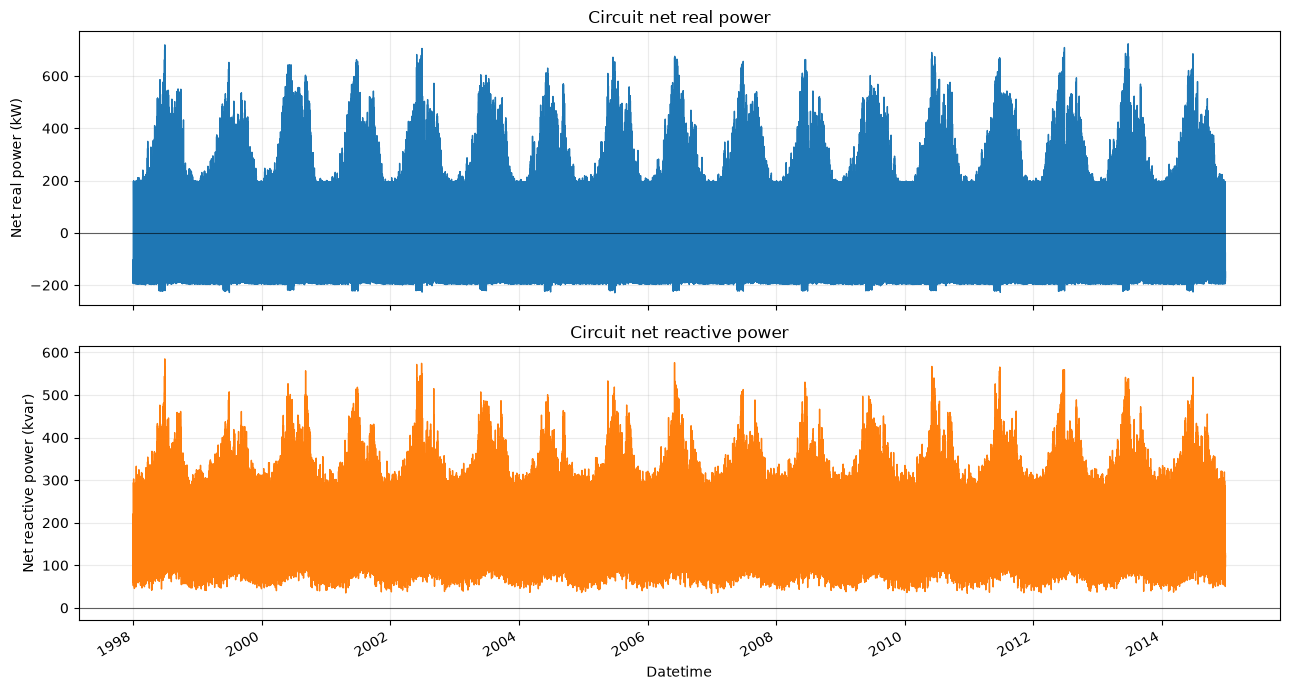

In [49]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

axes[0].plot(system_power["Datetime"], system_power["TotalKW"], linewidth=1)
axes[0].axhline(0, color="black", linewidth=0.8, alpha=0.6)
axes[0].set_ylabel("Net real power (kW)")
axes[0].set_title("Circuit net real power")
axes[0].grid(alpha=0.25)

axes[1].plot(
    system_power["Datetime"],
    system_power["TotalKvar"],
    color="tab:orange",
    linewidth=1,
)
axes[1].axhline(0, color="black", linewidth=0.8, alpha=0.6)
axes[1].set_ylabel("Net reactive power (kvar)")
axes[1].set_xlabel("Datetime")
axes[1].set_title("Circuit net reactive power")
axes[1].grid(alpha=0.25)

fig.autofmt_xdate()
fig.tight_layout()
plt.show()

## Building profiles applied to the feeder

The mapping table confirms which input profile was assigned to each DSS bus.

In [50]:
profile_bus_mapping = (
    applied_loads[["BuildingProfile", "Bus"]]
    .drop_duplicates()
    .sort_values("Bus")
    .reset_index(drop=True)
)
profile_bus_mapping

,BuildingProfile,Bus
0,PrimarySchoolKW,con_11
1,StripMallKW,con_12
2,WarehouseKW,con_13
3,Stand-aloneRetailKW,con_14
4,SecondarySchoolKW,con_15
5,SuperMarketKW,con_8
6,QuickServiceRestaurantKW,con_9


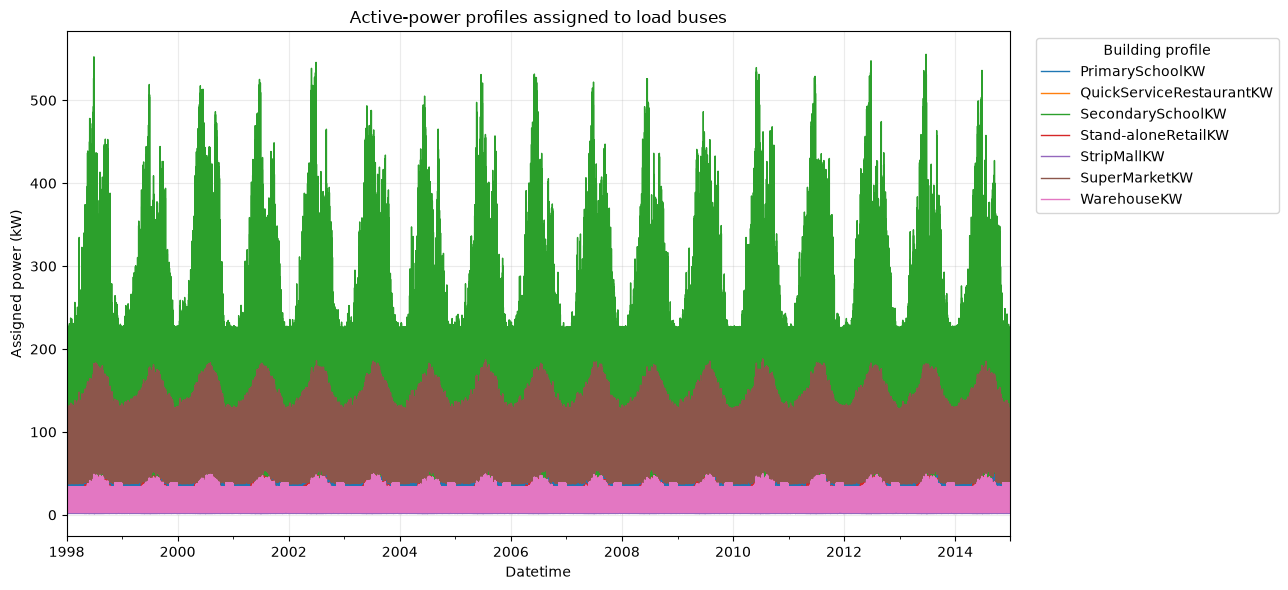

In [51]:
assigned_kw = applied_loads.pivot(
    index="Datetime", columns="BuildingProfile", values="AssignedKW"
)

ax = assigned_kw.plot(figsize=(13, 6), linewidth=1)
ax.set_title("Active-power profiles assigned to load buses")
ax.set_ylabel("Assigned power (kW)")
ax.set_xlabel("Datetime")
ax.grid(alpha=0.25)
ax.legend(title="Building profile", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Bus-level power

Select one or more buses below. Load power is normally positive; PV production is normally negative under the OpenDSS element sign convention. Buses without loads or PV systems will appear at zero because this table aggregates power-conversion elements rather than line flows.

In [52]:
available_buses = sorted(bus_power["Bus"].unique())
load_buses = list(profile_bus_mapping["Bus"])
pv_buses = [bus for bus in available_buses if bus.casefold() == "con_16"]
selected_buses = list(dict.fromkeys(load_buses + pv_buses))

print("Available buses:", available_buses)
print("Currently plotted:", selected_buses)

Available buses: ['con_10', 'con_11', 'con_12', 'con_13', 'con_14', 'con_15', 'con_16', 'con_2', 'con_3', 'con_4', 'con_5', 'con_6', 'con_7', 'con_8', 'con_9', 'src_1']
Currently plotted: ['con_11', 'con_12', 'con_13', 'con_14', 'con_15', 'con_8', 'con_9', 'con_16']


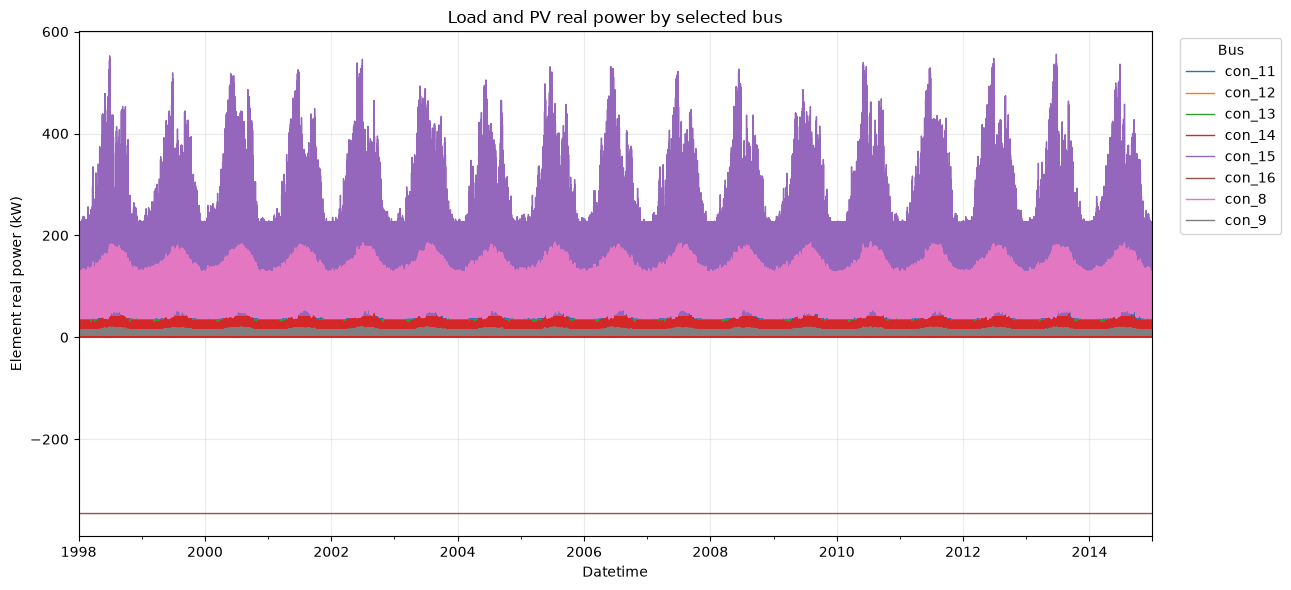

In [53]:
selected_bus_power = bus_power[bus_power["Bus"].isin(selected_buses)]
bus_kw = selected_bus_power.pivot(index="Datetime", columns="Bus", values="P_kW")

ax = bus_kw.plot(figsize=(13, 6), linewidth=1)
ax.axhline(0, color="black", linewidth=0.8, alpha=0.6)
ax.set_title("Load and PV real power by selected bus")
ax.set_ylabel("Element real power (kW)")
ax.set_xlabel("Datetime")
ax.grid(alpha=0.25)
ax.legend(title="Bus", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Peak conditions

The rows below identify the largest source import, largest source export, and largest reactive-power demand in the saved run.

In [54]:
peak_conditions = pd.DataFrame(
    {
        "Condition": [
            "Maximum source import",
            "Maximum source export",
            "Maximum reactive demand",
        ],
        "Datetime": [
            system_power.loc[system_power["TotalKW"].idxmax(), "Datetime"],
            system_power.loc[system_power["TotalKW"].idxmin(), "Datetime"],
            system_power.loc[system_power["TotalKvar"].idxmax(), "Datetime"],
        ],
        "Value": [
            system_power["TotalKW"].max(),
            system_power["TotalKW"].min(),
            system_power["TotalKvar"].max(),
        ],
        "Unit": ["kW", "kW", "kvar"],
    }
)
peak_conditions

,Condition,Datetime,Value,Unit
0,Maximum source import,2013-06-23 13:30:00,723.150460,kW
1,Maximum source export,2005-06-29 04:30:00,-229.351068,kW
2,Maximum reactive demand,1998-06-29 08:30:00,584.769384,kvar


## Optional date-range filtering

For a full-year run, use this pattern to focus later calculations on a smaller period. Change the dates to match the interval of interest.

In [55]:
start_date = system_power["Datetime"].min()
end_date = min(start_date + pd.Timedelta(days=7), system_power["Datetime"].max())

date_mask = system_power["Datetime"].between(start_date, end_date)
filtered_system_power = system_power.loc[date_mask].copy()
filtered_system_power

,Datetime,TotalKW,TotalKvar
0,1998-01-01 00:00:00,-186.313976,111.925081
1,1998-01-01 00:30:00,-193.252073,93.323908
2,1998-01-01 01:00:00,-188.872716,111.901908
3,1998-01-01 01:30:00,-185.391560,115.842329
4,1998-01-01 02:00:00,-180.808435,117.805172
...,...,...,...
332,1998-01-07 22:00:00,-181.673038,90.640318
333,1998-01-07 22:30:00,-187.018899,89.154086
334,1998-01-07 23:00:00,-159.708555,101.641344
335,1998-01-07 23:30:00,-167.159114,128.729590
